In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import backtrader as bt
import matplotlib.pyplot as plt
import pyfolio as pf
import quantstats as qs
import mplfinance as mpf
import pyarrow as pa
import pyarrow.parquet as pq

/Users/Jason/work/source/03_ThorpAI/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
import sys
sys.path.append('/Users/Jason/work/01 - source/03_ThorpAI')

In [14]:
from btc_model.core.util.performance_util import PerformanceUtil
from btc_model.core.util.io_util import IOCsv


file_name = '/Users/Jason/Downloads/数字货币市场中性策略回测底稿_单利_20250911.csv'

io_csv = IOCsv()

data = io_csv.load_file(file_name, index_col=None, header=0)

print(data)

            date     value  compound_value  maxdd
0     2021-08-24  1.002258        1.000000  0.00%
1     2021-08-25  0.990707        0.988475  1.17%
2     2021-08-26  1.000298        0.997933  0.21%
3     2021-08-27  0.999948        0.997585  0.24%
4     2021-08-28  1.016880        1.014439  0.00%
...          ...       ...             ...    ...
1459  2025-08-22  3.293687        9.060795  0.20%
1460  2025-08-23  3.293707        9.060976  0.20%
1461  2025-08-24  3.292478        9.049860  0.32%
1462  2025-08-25  3.294511        9.068222  0.12%
1463  2025-08-26  3.298055        9.100287  0.00%

[1464 rows x 4 columns]


In [15]:
data_value = data[['date', 'compound_value']].reset_index(drop=True)
data_value['date'] = pd.to_datetime(data_value['date'])
# df_data['value'] = df_data['value'].pct_change()
data_value['compound_value'] =data_value['compound_value'] / data_value['compound_value'].iloc[0]

In [16]:
# 假设df是您的DataFrame（如截图所示）
# 首先确保date列是datetime类型
data_value['date'] = pd.to_datetime(data_value['date'])

# 过滤日期 >= '2022-01-01'
filtered_df = data_value[data_value['date'] >= '2021-01-01']

# 重置索引（可选）
filtered_df = filtered_df.reset_index(drop=True)

# 查看结果
print(filtered_df)

           date  compound_value
0    2021-08-24        1.000000
1    2021-08-25        0.988475
2    2021-08-26        0.997933
3    2021-08-27        0.997585
4    2021-08-28        1.014439
...         ...             ...
1459 2025-08-22        9.060795
1460 2025-08-23        9.060976
1461 2025-08-24        9.049860
1462 2025-08-25        9.068222
1463 2025-08-26        9.100287

[1464 rows x 2 columns]


In [17]:
from btc_model.core.util.performance_util import PerformanceUtil

perf = PerformanceUtil(data=filtered_df, simple_interest=False)




In [17]:
df = pd.DataFrame(perf.compound_value)

In [18]:
df.to_csv('/Users/Jason/Downloads/数字货币市场中性策略回测底稿_复利_20250911.csv.csv', index=False)

In [18]:
print(f'年化收益率: {perf.yearly_profit(False)}')
print(f'年化波动率: {perf.yearly_volatility()}')
print(f'最大回撤: {perf.max_drawdown()}')
print(f'夏普比率: {perf.yearly_sharpe_ratio()}')
print(f'胜率: {perf.win_rate()}')
print(f'盈亏比: {perf.profit_and_loss_ratio()}')

年化收益率: 0.4584280527323441
年化波动率: 0.16712380113249053
最大回撤: 0.12446756204970878
夏普比率: 2.34213077582129
胜率: 0.543403964456596
盈亏比: 1.328794488122385


In [19]:
perf.return_by_year()

/Users/Jason/work/source/03_ThorpAI/btc_model/core/util/performance_util.py:250: FutureWarning: The provided callable <function sum at 0x10706eca0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  yearly_sum = group_by_year.agg({'return': np.sum})


,return
year,
2021,0.545880
2022,0.462681
2023,0.516092
2024,0.652408
2025,0.113562


In [24]:
perf.return_by_month() 

,year_month,monthly_return
0,2021-08,0.094019
1,2021-09,0.102010
2,2021-10,0.403124
3,2021-11,-0.042260
4,2021-12,-0.011014
5,2022-01,0.014918
6,2022-02,0.066006
7,2022-03,0.146526
8,2022-04,-0.027440
9,2022-05,0.031139


/var/folders/_z/81vrdcld57l7zkfxcyy9_qv40000gp/T/ipykernel_20012/3255811556.py:10: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_z/81vrdcld57l7zkfxcyy9_qv40000gp/T/ipykernel_20012/3255811556.py:10: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_z/81vrdcld57l7zkfxcyy9_qv40000gp/T/ipykernel_20012/3255811556.py:10: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_z/81vrdcld57l7zkfxcyy9_qv40000gp/T/ipykernel_20012/3255811556.py:10: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_z/81vrdcld57l7zkfxcyy9_qv40000gp/T/ipykernel_20012/3255811556.py:10: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_z/81vrdcld57l7zkfxcyy9_qv40000gp/T/i

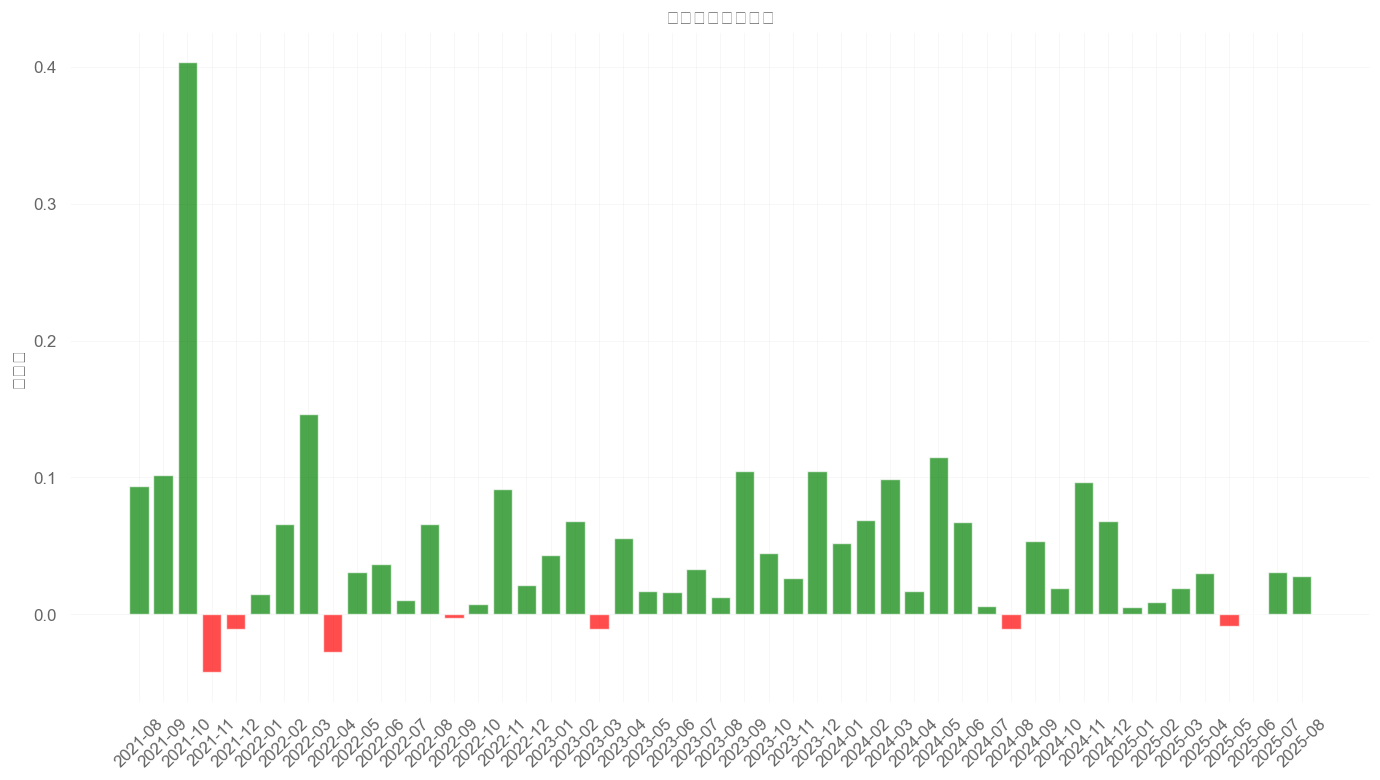

In [23]:
result =perf.return_by_month() 

plt.figure(figsize=(14, 8))
colors = ['green' if x >= 0 else 'red' for x in result['monthly_return']]
plt.bar(result['year_month'], result['monthly_return'], color=colors, alpha=0.7)
plt.xticks(rotation=45)
plt.title('月度收益率柱状图')
plt.ylabel('收益率')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()